In [4]:
# Here’s a ready-to-use assessment scenario for students learning transfer learning in computer vision,
# tailored to satellite image classification:

# 🛰️ Assessment Scenario: Transfer Learning for Land Cover Classification
# Context
# You are part of a geospatial AI team working with satellite imagery to monitor land use changes.
# Your task is to build a model that classifies satellite images into three categories:
# Urban
# Forest
# Water
# Due to limited labeled data and compute resources, training a deep CNN from scratch is not practical.

# Challenge
# Apply transfer learning using a pre-trained ResNet50 model (trained on ImageNet) to classify satellite
# images into the three land cover types.

In [ ]:
import torch
import torchvision
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# 1) Load EuroSAT from torchvision
# ----------------------------
# Torchvision provides EuroSAT and can download it automatically. [1](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.EuroSAT.html)

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),   # ResNet50 expects ~224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

base_ds = torchvision.datasets.EuroSAT(
    root="data",
    download=True,
    transform=None  # we'll apply transforms after filtering
)

# EuroSAT classes include Residential, Industrial, Forest, River, SeaLake etc. [4](https://www.kaggle.com/datasets/apollo2506/eurosat-dataset)[3](https://github.com/Sood-Akriti/EuroSat)
print("EuroSAT classes:", base_ds.classes)

# ----------------------------
# 2) Remap EuroSAT -> 3 classes (Urban / Forest / Water)
# ----------------------------
# Suggested mapping using EuroSAT's land-use classes. [4](https://www.kaggle.com/datasets/apollo2506/eurosat-dataset)[3](https://github.com/Sood-Akriti/EuroSat)

URBAN = {"Residential", "Industrial"}   # optionally add "Highway"
FOREST = {"Forest"}
WATER = {"River", "SeaLake"}

name_to_idx = {name: i for i, name in enumerate(base_ds.classes)}

selected = {}
for c in URBAN:
    selected[name_to_idx[c]] = 0  # Urban
for c in FOREST:
    selected[name_to_idx[c]] = 1  # Forest
for c in WATER:
    selected[name_to_idx[c]] = 2  # Water

class_names = ["Urban", "Forest", "Water"]

class EuroSAT3Class(Dataset):
    def __init__(self, eurosat_ds, transform):
        self.ds = eurosat_ds
        self.transform = transform
        # keep only samples whose label is in selected mapping
        self.keep_indices = [
            i for i, (_, y) in enumerate(self.ds.samples)
            if y in selected
        ]

    def __len__(self):
        return len(self.keep_indices)

    def __getitem__(self, idx):
        real_idx = self.keep_indices[idx]
        img, y = self.ds[real_idx]  # returns PIL image and label index [1](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.EuroSAT.html)
        y3 = selected[y]
        if self.transform:
            img = self.transform(img)
        return img, y3

full_ds = EuroSAT3Class(base_ds, transform=train_tfms)

# Split train/val/test
n = len(full_ds)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val
train_ds, val_ds, test_ds = random_split(full_ds, [n_train, n_val, n_test])

# Give val/test deterministic transforms
val_ds.dataset.transform = val_tfms
test_ds.dataset.transform = val_tfms

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

# ----------------------------
# 3) Transfer learning with ResNet50
# ----------------------------
model = torchvision.models.resnet50(
    weights=torchvision.models.ResNet50_Weights.DEFAULT
)

# Freeze backbone
for p in model.parameters():
    if "layer 4" or "fc" in p:
        p.requires_grad = True

# Replace head for 3 classes
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

# ----------------------------
# 4) Train + Validate
# ----------------------------
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            if training:
                optimizer.zero_grad()

            logits = model(x)
            loss = criterion(logits, y)

            if training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total

epochs = 15
for ep in range(epochs):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    va_loss, va_acc = run_epoch(val_loader, training=False)
    print(f"Epoch {ep+1}/{epochs} | Train loss {tr_loss:.4f} acc {tr_acc:.4f} | Val loss {va_loss:.4f} acc {va_acc:.4f}")

# ----------------------------
# 5) Test evaluation
# ----------------------------
te_loss, te_acc = run_epoch(test_loader, training=False)
print(f"Test loss {te_loss:.4f} | Test acc {te_acc:.4f}")
print("Final classes:", class_names)

EuroSAT classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Epoch 1/15 | Train loss 0.2132 acc 0.9420 | Val loss 0.0944 acc 0.9748
Epoch 2/15 | Train loss 0.0923 acc 0.9726 | Val loss 0.0624 acc 0.9829
Epoch 3/15 | Train loss 0.0776 acc 0.9750 | Val loss 0.0585 acc 0.9819
Epoch 4/15 | Train loss 0.0620 acc 0.9804 | Val loss 0.0491 acc 0.9843
Epoch 5/15 | Train loss 0.0518 acc 0.9853 | Val loss 0.0402 acc 0.9890
Epoch 6/15 | Train loss 0.0546 acc 0.9832 | Val loss 0.0407 acc 0.9871
Epoch 7/15 | Train loss 0.0471 acc 0.9840 | Val loss 0.0417 acc 0.9876
Epoch 8/15 | Train loss 0.0485 acc 0.9847 | Val loss 0.0319 acc 0.9914
Epoch 9/15 | Train loss 0.0370 acc 0.9886 | Val loss 0.0317 acc 0.9900
Epoch 10/15 | Train loss 0.0373 acc 0.9881 | Val loss 0.0311 acc 0.9910
Epoch 11/15 | Train loss 0.0381 acc 0.9885 | Val loss 0.0296 acc 0.9919
Epoch 12/15 | Train loss 0.0338 acc 0.9900 | Val loss 0.0300 ac

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# ImageNet normalization you used
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def unnormalize(img_tensor):
    """img_tensor: (3,H,W) normalized. Returns (H,W,3) in [0,1]."""
    img = img_tensor.cpu() * STD + MEAN
    img = img.clamp(0, 1)
    return np.transpose(img.numpy(), (1, 2, 0))

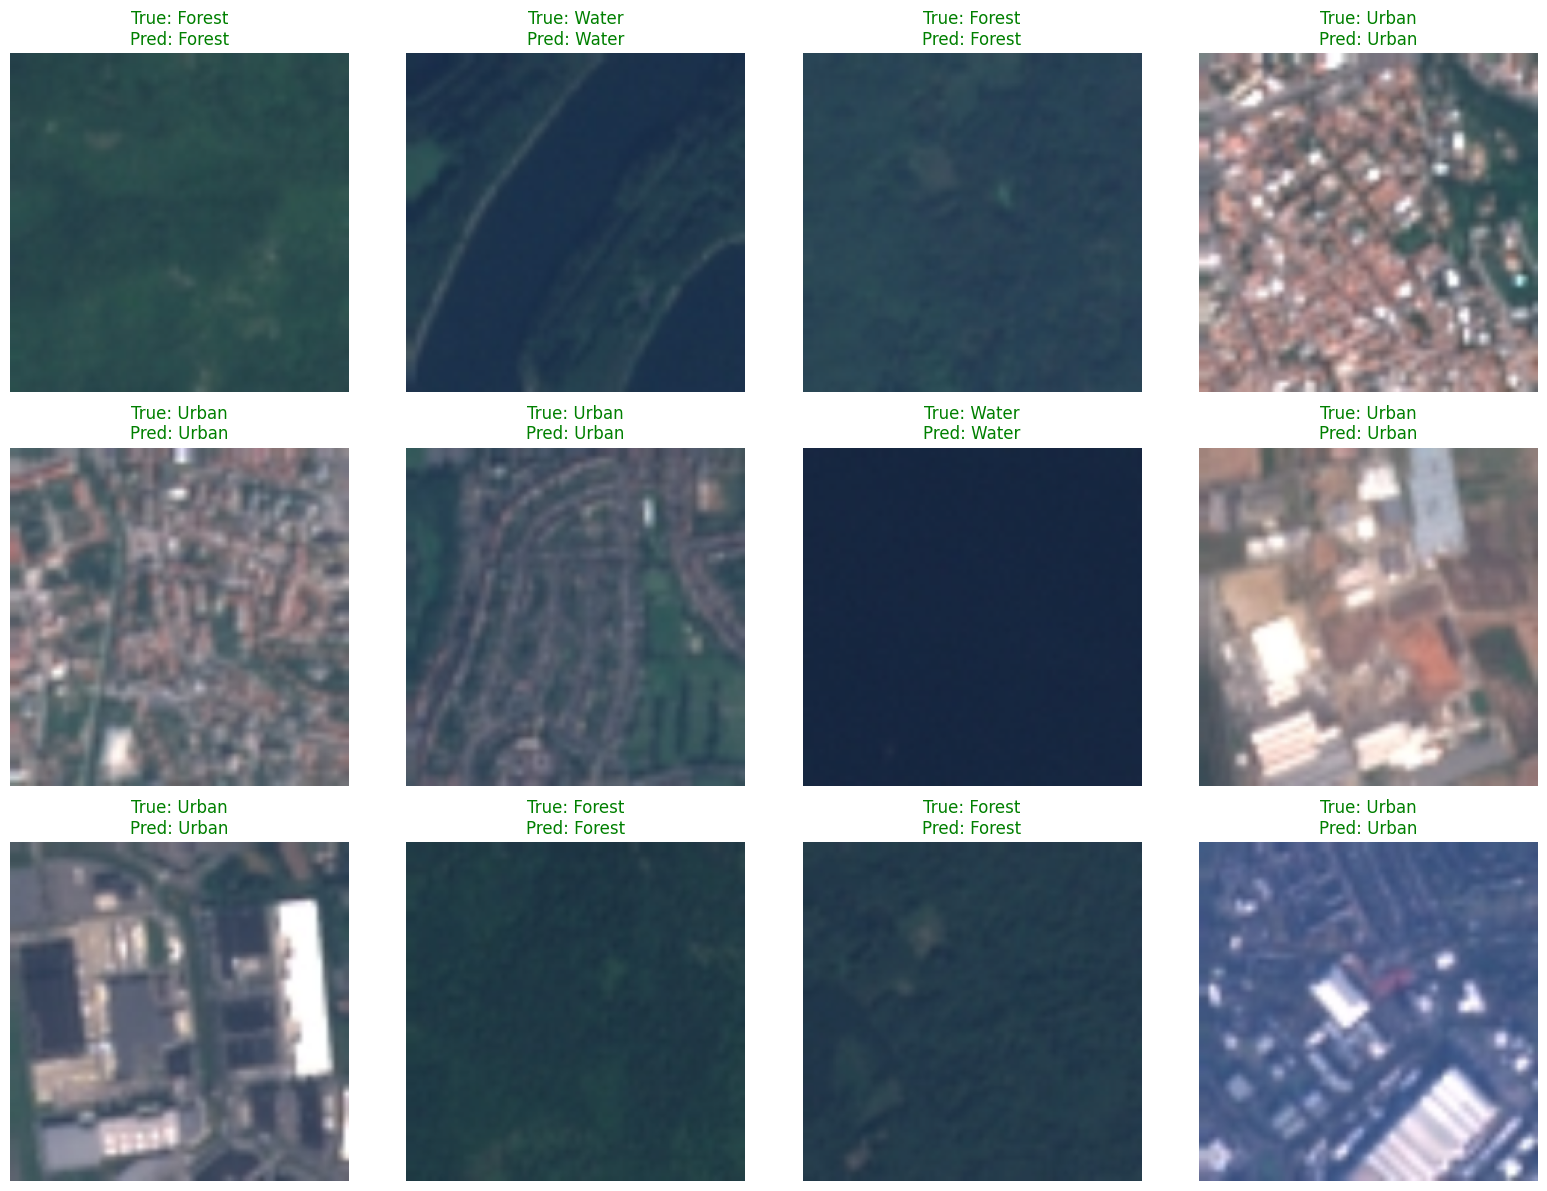

In [32]:
import random

@torch.no_grad()
def show_test_predictions(model, test_loader, class_names, n=12):
    model.eval()

    # Grab one batch
    x, y = next(iter(test_loader))
    x, y = x.to(device), y.to(device)

    # Predict
    logits = model(x)
    preds = logits.argmax(1)

    # Plot (up to n images)
    n = min(n, x.size(0))
    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(4*cols, 4*rows))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(unnormalize(x[i]))
        t = class_names[y[i].item()]
        p = class_names[preds[i].item()]
        color = "green" if t == p else "red"
        plt.title(f"True: {t}\nPred: {p}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_test_predictions(model, test_loader, class_names, n=12)

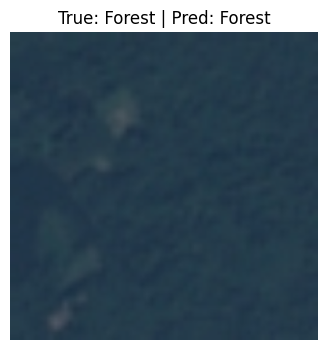

1

In [33]:
@torch.no_grad()
def predict_single_from_testset(model, test_ds, idx, class_names):
    model.eval()
    img, label = test_ds[idx]              # img is already transformed (tensor)
    x = img.unsqueeze(0).to(device)

    logits = model(x)
    pred = logits.argmax(1).item()

    plt.figure(figsize=(4,4))
    plt.imshow(unnormalize(img))
    plt.title(f"True: {class_names[label]} | Pred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    return pred

# Example: show the 10th test image
predict_single_from_testset(model, test_ds, idx=10, class_names=class_names)

File: water.jpg
  Water: 0.9923
  Urban: 0.0071
  Forest: 0.0006


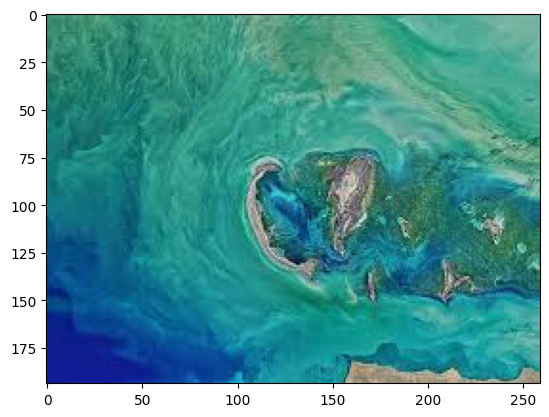

In [50]:
from PIL import Image
import torch.nn.functional as F

image = Image.open("water.jpg")
plt.imshow(image)

@torch.no_grad()
def predict_image_path_verbose(model, image_path, transform, class_names):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)

    logits = model(x)
    probs = F.softmax(logits, dim=1).squeeze(0).cpu()

    top = torch.argsort(probs, descending=True)
    print("File:", image_path)
    for i in top.tolist():
        print(f"  {class_names[i]}: {probs[i].item():.4f}")

val_tfms_crop = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
predict_image_path_verbose(model, "water.jpg", val_tfms_crop, class_names)

In [42]:
# Evaluate quickly on EuroSAT test set (your mapped 3-class test_loader)
te_loss, te_acc = run_epoch(test_loader, training=False)
print("Test acc:", te_acc)

Test acc: 0.9914285714285714
